In [1]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!pip install ultralytics==8.2.80 -q
!pip install opencv-python==4.10.0.84 -q
!pip install matplotlib -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.54  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
Setup complete  (12 CPUs, 15.8 GB RAM, 416.5/634.8 GB disk)


In [14]:
import os
import numpy as np
import cv2
import sys
import time
import requests
import zipfile
from os import path
import matplotlib.pyplot as plt
%matplotlib inline

from ultralytics.utils import YAML
from ultralytics.utils.checks import check_yaml

In [8]:
def download_and_unzip(dropbox_link):
    output_dir = '.'

    # get clean filename without query params
    filename = dropbox_link.split('/')[-1].split('?')[0]

    # ensure direct download by forcing dl=1
    if '?' in dropbox_link:
        direct_link = dropbox_link + '&dl=1'
    else:
        direct_link = dropbox_link + '?dl=1'

    print(f'Downloading {filename}...')
    response = requests.get(direct_link)
    
    # verify we got a zip file, not an HTML page
    content_type = response.headers.get('content-type', '')
    print(f'Content-Type: {content_type}')
    
    if 'html' in content_type:
        print('ERROR: Got HTML page instead of zip file — link may be expired or private')
        return

    zip_path = os.path.join(output_dir, filename)
    with open(zip_path, 'wb') as f:
        f.write(response.content)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    os.remove(zip_path)
    print(f'Extracted to: {output_dir}')

In [9]:
dropbox_link = "https://www.dropbox.com/scl/fi/exg6o6greg7cp2uq98wll/yolov8-opencvdnn.zip?rlkey=2br0c8r1fjrqgyf6i362xfxrd&st=9lmmh6t5"
download_and_unzip(dropbox_link)

Content-Type: application/binary
Extracted to: .


In [10]:
plt.rcParams['figure.figsize'] = (15.0,15.0)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14

In [11]:
from ultralytics import YOLO

# Load the YOLOv8 model
model = YOLO("yolov8s.pt") # change according to your need between YOLOv8 and YOLOv9 both will works

# Export the model to ONNX format
model.export(format="onnx")  # creates 'yolov8n.onnx'

Ultralytics 8.4.54  Python-3.11.15 torch-2.12.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs

PyTorch: starting from 'yolov8s.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (21.5 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  2.3s, saved as 'yolov8s.onnx' (42.8 MB)

Export complete (2.9s)
Results saved to F:\Opencv-Git\Learning-OpenCV\Mastering OpenCV with Python\Week 15\yolov8s.onnx
Predict:         yolo predict task=detect model=yolov8s.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8s.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app


'yolov8s.onnx'

In [12]:
# Constants
INPUT_WIDTH = 640
INPUT_HEIGHT = 640
CONFIDENCE_THRESHOLD = 0.5
NMS_THRESHOLD = 0.4

# Text parameters.
FONT_FACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 1
THICKNESS = 2

In [16]:
# Load the class names from the COCO dataset
CLASSES = YAML.load(check_yaml("coco8.yaml"))["names"]

# Display all the CLASSES
for i in CLASSES.values():
  print(i)

# Generate a color palette for the classes
COLORS = np.random.uniform(0, 255, size=(len(CLASSES), 3))

person
bicycle
car
motorcycle
airplane
bus
train
truck
boat
traffic light
fire hydrant
stop sign
parking meter
bench
bird
cat
dog
horse
sheep
cow
elephant
bear
zebra
giraffe
backpack
umbrella
handbag
tie
suitcase
frisbee
skis
snowboard
sports ball
kite
baseball bat
baseball glove
skateboard
surfboard
tennis racket
bottle
wine glass
cup
fork
knife
spoon
bowl
banana
apple
sandwich
orange
broccoli
carrot
hot dog
pizza
donut
cake
chair
couch
potted plant
bed
dining table
toilet
tv
laptop
mouse
remote
keyboard
cell phone
microwave
oven
toaster
sink
refrigerator
book
clock
vase
scissors
teddy bear
hair drier
toothbrush


In [17]:
def draw_detections(img, box, score, class_id):

    # Extract the coordinates of the bounding box
    x1, y1, w, h = box

    # Retrieve the color for the class ID
    color = COLORS[class_id]

    # Draw the bounding box on the image
    cv2.rectangle(img, (int(x1), int(y1)), (int(x1 + w), int(y1 + h)), color, 2)

    # Create the label text with class name and score
    label = f"{CLASSES[class_id]}: {score:.2f}"

    # Calculate the dimensions of the label text
    (label_width, label_height), _ = cv2.getTextSize(label, FONT_FACE, FONT_SCALE, THICKNESS)

    # Calculate the position of the label text
    label_x = x1
    label_y = y1 - 10 if y1 - 10 > label_height else y1 + 10

    # Draw a filled rectangle as the background for the label text
    cv2.rectangle(
        img, (label_x, label_y - label_height), (label_x + label_width, label_y + label_height), color, cv2.FILLED
    )

    # Draw the label text on the image
    cv2.putText(img, label, (label_x, label_y), FONT_FACE, FONT_SCALE, (0, 0, 0), THICKNESS, cv2.LINE_AA)

In [18]:
def inference(input_image, net):

    # Create a 4D blob from a frame.
    blob = cv2.dnn.blobFromImage(input_image, 1/255, (INPUT_WIDTH, INPUT_HEIGHT), [0,0,0], 1, crop=False)

    # Sets the input to the network.
    net.setInput(blob)

    # Runs the forward pass to get output of the output layers.
    output_layers = net.getUnconnectedOutLayersNames()
    image_data = net.forward(output_layers)

    # Return the preprocessed image data
    return image_data

In [19]:
def postprocess(input_image, output):

    # Transpose and squeeze the output to match the expected shape
    outputs = np.transpose(np.squeeze(output[0]))

    # Get the number of rows in the outputs array
    rows = outputs.shape[0]

    # Lists to store the bounding boxes, scores, and class IDs of the detections
    boxes = []
    scores = []
    class_ids = []

    img_height, img_width = input_image.shape[:2]

    # Calculate the scaling factors for the bounding box coordinates
    x_factor = img_width / INPUT_WIDTH
    y_factor = img_height / INPUT_HEIGHT

    # Iterate over each row in the outputs array
    for i in range(rows):
        # Extract the class scores from the current row
        classes_scores = outputs[i][4:]

        # Find the maximum score among the class scores
        max_score = np.amax(classes_scores)

        # If the maximum score is above the confidence threshold
        if max_score >= CONFIDENCE_THRESHOLD:
            # Get the class ID with the highest score
            class_id = np.argmax(classes_scores)

            # Extract the bounding box coordinates from the current row
            x, y, w, h = outputs[i][0], outputs[i][1], outputs[i][2], outputs[i][3]

            # Calculate the scaled coordinates of the bounding box
            left = int((x - w / 2) * x_factor)
            top = int((y - h / 2) * y_factor)
            width = int(w * x_factor)
            height = int(h * y_factor)

            # Add the class ID, score, and box coordinates to the respective lists
            class_ids.append(class_id)
            scores.append(max_score)
            boxes.append([left, top, width, height])

    # Apply non-maximum suppression to filter out overlapping bounding boxes
    indices = cv2.dnn.NMSBoxes(boxes, scores, CONFIDENCE_THRESHOLD, NMS_THRESHOLD)

    # Iterate over the selected indices after non-maximum suppression
    for i in indices:
        # Get the box, score, and class ID corresponding to the index
        box = boxes[i]
        score = scores[i]
        class_id = class_ids[i]

        # Draw the detection on the input image
        draw_detections(input_image, box, score, class_id)

    # Return the modified input image
    return input_image

In [20]:
def put_efficiency(input_img, inference_time, is_video=False):
    if is_video:
        # Calculate FPS based on inference time
        fps = 1 / inference_time
        label = 'FPS: %.2f' % fps
    else:
        # Convert the timing information to milliseconds and create a label string
        label = 'Inference Time: %.2f ms' % (inference_time * 1000.0)

    # Print the efficiency information to the console
    # print(label)

    # Display the efficiency information on the input image
    cv2.putText(input_img, label, (10, 50), FONT_FACE, FONT_SCALE, (0, 255, 0), THICKNESS, cv2.LINE_AA)

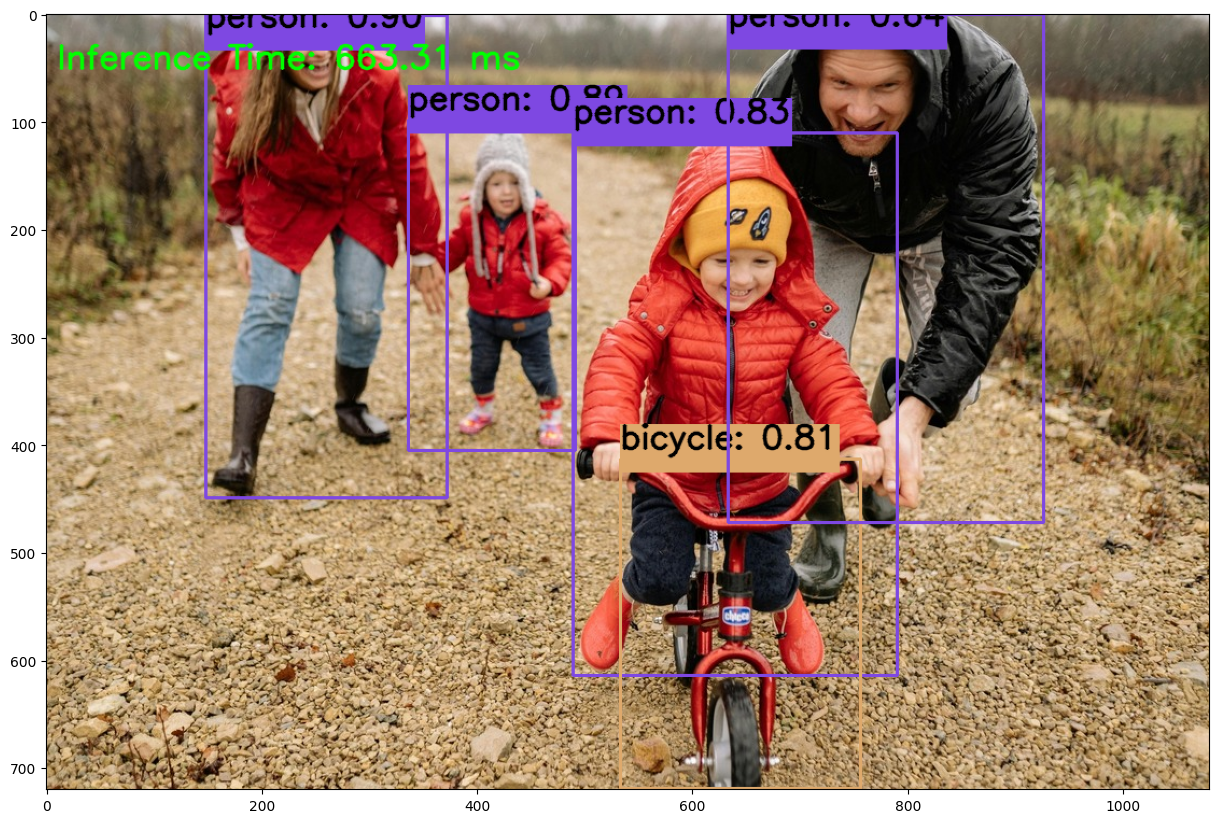

In [21]:
#Load the Image
frame = cv2.imread('family.jpg', cv2.IMREAD_UNCHANGED)

# Load the network.
model = "yolov8s.onnx"
net = cv2.dnn.readNetFromONNX(model)

# Start the timer
start_time = time.time()

# Process image.
detections = inference(frame, net)

# Measure inference time
inference_time = time.time() - start_time

# Do the Post processing
img = postprocess(frame.copy(), detections)

# Put efficiency information.
put_efficiency(img, inference_time, is_video=False)

# save the final image
cv2.imwrite('result.jpg', img)

plt.imshow(img[...,::-1]);

In [22]:
# Load the network
model = "yolov8s.onnx"
net = cv2.dnn.readNetFromONNX(model)

# Video input
video_path = '/content/birds-side-view.mp4'  # replace with your video path
cap = cv2.VideoCapture(video_path)

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
output_path = 'output_video.mp4'  # replace with your desired output path

# Initialize VideoWriter to save the output video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("End of video stream")
        break

    # Start the timer
    start_time = time.time()

    # Process each frame
    detections = inference(frame, net)

    # Measure inference time
    inference_time = time.time() - start_time

    # Do the post processing
    img = postprocess(frame.copy(), detections)

    # Calculate and display the FPS or inference time on the frame
    put_efficiency(img, inference_time, is_video=True)

    # Write the processed frame to the output video
    out.write(img)

    # Display the processed frame
    # cv2.imshow('YOLOv8 Object Detection', img)

    # Press 'q' to exit the video loop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release video capture and writer, and close windows
cap.release()
out.release()
cv2.destroyAllWindows()